In [3]:
import numpy as np
import pandas as pd
import os
import mat73
from sklearn import svm
from sklearn import metrics
import scipy.io
from scipy import stats
import matplotlib.pyplot as plt
from scipy import stats, linalg
import warnings
import joblib

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.base")

from sklearn.exceptions import ConvergenceWarning
def conv_r2z(r):
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))
def conv_z2r(z):
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

# load the arousal SVR

In [4]:
# Load the model (optional if you just saved it)
clf = joblib.load('./svr_model.pkl')
print('Model loaded successfully!')

Model loaded successfully!


In [6]:
# load the arousal network
arousal_network = scipy.io.loadmat('./arousal_network.mat')['arousal_network']

# load the feature ids
nR = 122 # the Yeo 114 atlas for cortical regions + Brainnectome atlas for subcortical
# for the Brainnectome atlas, follow this order: left amygdala, hippocampus, basal ganglia, and thalamus, then right amygdala, hippocampus, basal ganglia, and thalamus
feat_id = []
ii = -1
for i in range(nR-1):
    for j in range(i+1,nR):
        ii = ii + 1
        if arousal_network[i,j] != 0: # this includes both positive and negative features
            feat_id.append(ii)
feat_id = np.array(feat_id)
print('Arousal network loaded. It has',len(feat_id),'FC features')

Arousal network loaded. It has 237 FC features


# load your own testing data -- e.g., Merlin

In [8]:
# load brain -- Chatter Dataset
# The format of the brain data should be nsubj*nFC*nTR

# 1. Using scipy instead of mat73 since NSG output is standard .mat
brain_chatter = scipy.io.loadmat(r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\04_data\output\chatter_NSG_job\sliding-dynFeat-Chatter.mat')['dynFeat']

# 2. Z-scoring per feature
brain_chatter = scipy.stats.zscore(brain_chatter, 2, nan_policy='omit') 

# 3. Applying the 122 parcel mask
# NOTE: Removed the '16:' slice here so you keep all 419 TR
dynFC_test = brain_chatter[:, feat_id, :] 

print('  model learn: brain entire feature shape ' + str(dynFC_test.shape))

  model learn: brain entire feature shape (30, 237, 419)


In [9]:
# check for any missing TRs
nanidx = []
for subj in range(dynFC_test.shape[0]):
    for ft in range(dynFC_test.shape[1]):
        if np.any(np.isnan(dynFC_test[subj,ft,:])):
            nanidx.append(ft)

nanidx = np.unique(nanidx)
print('NaN = '+str(nanidx))

if len(nanidx)>0:
    dynFC_test = np.delete(dynFC_test,nanidx,1)

print('Number of nans in selected FC: '+str(len(nanidx)))
print('DynFC_test Shape: '+str(dynFC_test.shape))

NaN = []
Number of nans in selected FC: 0
DynFC_test Shape: (30, 237, 419)


# apply the model to your own fMRI data, to predict the moment-to-moment arousal fluctuations of each participant

In [ ]:

test_nsubj = 30 
predicted_arousal = []

for test_sub in range(test_nsubj):
    test_feat = dynFC_test[test_sub, :, :]
    rmtr_test = []
    
    for tm in range(test_feat.shape[1]):
        if np.all(np.isnan(test_feat[:, tm])):
            rmtr_test.append(tm)
            
    rmtr_test = np.asarray(rmtr_test)
    if len(rmtr_test) > 0:
        test_feat = np.delete(test_feat, rmtr_test, 1)
        
    
    predicted = clf.predict(test_feat.T)
    predicted_arousal.append(predicted)

predicted_arousal = np.array(predicted_arousal)

#saving the predictions
save_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Predicted_Arousal_Chatter.npy'
np.save(save_path, predicted_arousal)
print(f"Success! Predictions saved to: {save_path}")

Success! Predictions saved to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Predicted_Arousal_Chatter.npy


Loaded Predictions Shape: (30, 419)

--- Loading IntenseEmotion TSV Data ---
Loaded IntenseEmotion Shape: (405,) (Expected: ~405)

--- Correlation Results ---
Cohort Average Pearson r: 0.9019 (p-value: 1.0767e-114)
Mean Subject-Level Pearson r: 0.4582


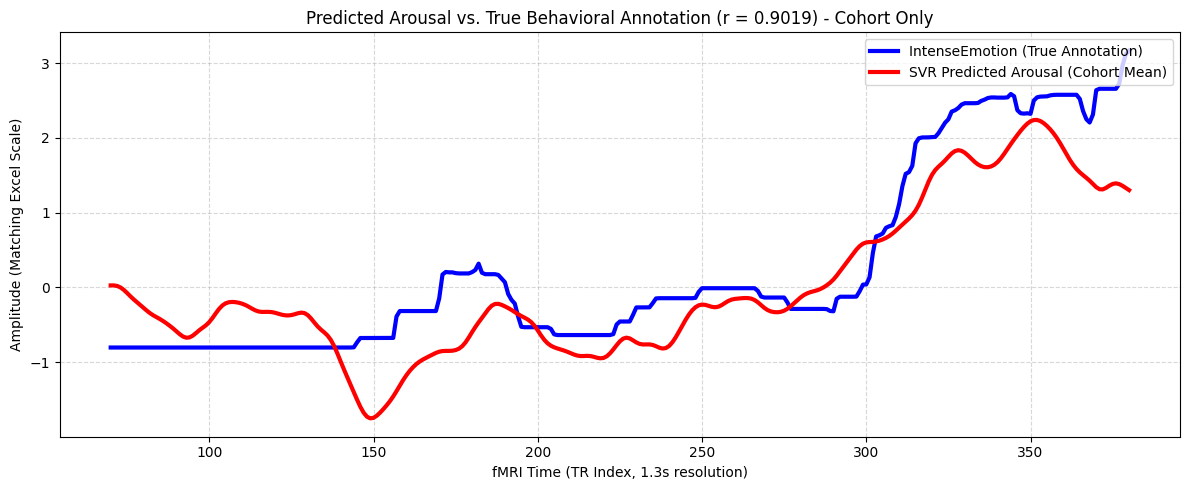

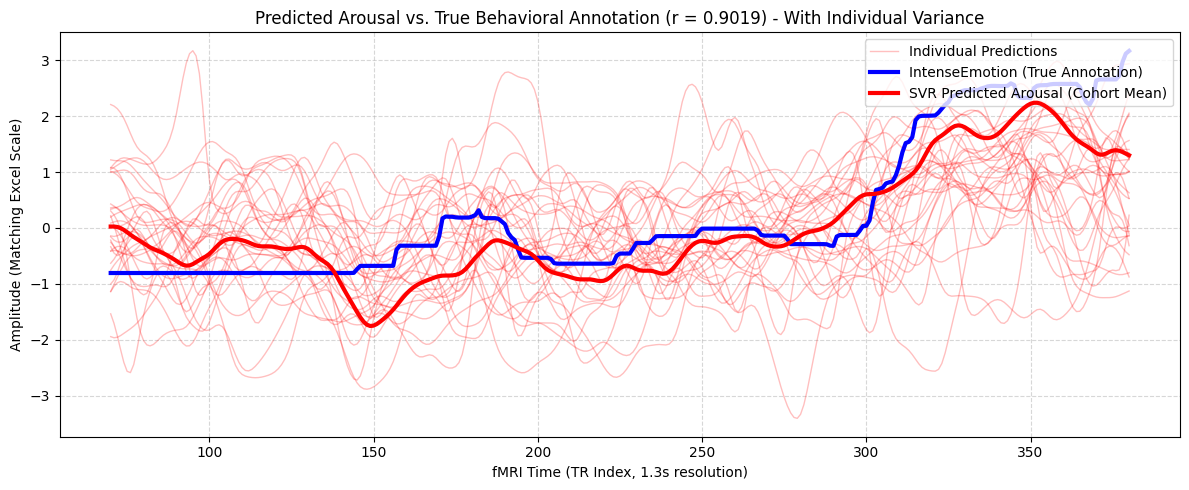

In [11]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD PREDICTIONS
# ==========================================
pred_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Chatter\Predicted_Arousal_Chatter.npy'
predicted_arousal = np.load(pred_path)
print(f"Loaded Predictions Shape: {predicted_arousal.shape}")

# ==========================================
# 2. LOAD & PARSE BEHAVIORAL ANNOTATIONS
# ==========================================
print("\n--- Loading IntenseEmotion TSV Data ---")
emotion_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\data\annotation_files\Annot_Chatter_stim.tsv'

json_columns = [
    "Standards", "PleasantSelf", "SocialNorms", "PleasantOther", "GoalsOther",
    "Controlled", "Predictable", "Suddenly", "Agent", "Urgency", "Lips",
    "Tears", "Eyebrows", "Smile", "Frown", "Stop", "Undo", "Repeat",
    "Oppose", "Attention", "Tackle", "Command", "Support", "Move", "Care",
    "Bad", "Good", "Calm", "Strong", "IntenseEmotion", "Alert", "AtEase",
    "Muscle", "Heartrate", "Throat", "Stomach", "Warm", "Anger", "Guilt",
    "WarmHeartedness", "Disgust", "Happiness", "Fear", "Regard", "Anxiety",
    "Satisfaction", "Pride", "Surprise", "Love", "Sad"
]

emotion_df = pd.read_csv(emotion_path, sep='\t', header=None, names=json_columns)

intense_emotion_1hz = emotion_df['IntenseEmotion'].values
movie_duration_sec = len(intense_emotion_1hz)
print(f"Loaded IntenseEmotion Shape: {intense_emotion_1hz.shape} (Expected: ~405)")

# ==========================================
# 3. GLOBAL TEMPORAL ALIGNMENT (SECONDS)
# ==========================================
tr_duration = 1.3
total_scan_trs = 464
window_size = 45

all_tr_times = np.arange(total_scan_trs) * tr_duration

pred_window_centers_tr = np.arange(predicted_arousal.shape[1]) + (window_size / 2.0)
pred_times_sec = pred_window_centers_tr * tr_duration

annot_start_sec = 90.0
annot_times_sec = np.arange(movie_duration_sec) + annot_start_sec

# ==========================================
# 4. ISOLATE AND RESAMPLE THE MOVIE BLOCK
# ==========================================
movie_tr_mask = (all_tr_times >= annot_start_sec) & (all_tr_times <= (annot_start_sec + movie_duration_sec))
movie_tr_times = all_tr_times[movie_tr_mask]

annot_interpolator = interp1d(annot_times_sec, intense_emotion_1hz, kind='linear', bounds_error=False, fill_value='extrapolate')
emotion_at_trs = annot_interpolator(movie_tr_times)

mean_predicted_arousal = np.mean(predicted_arousal, axis=0)
pred_interpolator = interp1d(pred_times_sec, mean_predicted_arousal, kind='linear', bounds_error=False, fill_value='extrapolate')
pred_at_trs = pred_interpolator(movie_tr_times)

# ==========================================
# 5. STATISTICAL VALIDATION
# ==========================================
print("\n--- Correlation Results ---")
r_group, p_group = pearsonr(emotion_at_trs, pred_at_trs)
print(f"Cohort Average Pearson r: {r_group:.4f} (p-value: {p_group:.4e})")

subject_rs = []
subject_preds_at_trs = []  

for subj in range(predicted_arousal.shape[0]):
    subj_pred_interpolator = interp1d(pred_times_sec, predicted_arousal[subj, :], kind='linear', bounds_error=False, fill_value='extrapolate')
    subj_pred_at_trs = subj_pred_interpolator(movie_tr_times)
    
    r_val, _ = pearsonr(emotion_at_trs, subj_pred_at_trs)
    subject_rs.append(r_val)
    subject_preds_at_trs.append(subj_pred_at_trs)  

print(f"Mean Subject-Level Pearson r: {np.mean(subject_rs):.4f}")

# ==========================================
# 6. VISUAL PLOTTING
# ==========================================
movie_tr_indices = movie_tr_times / tr_duration

# Prepare the properly scaled cohort average 
norm_pred = (pred_at_trs - np.mean(pred_at_trs)) / (np.std(pred_at_trs) + 1e-8)

# ---------------------------------------------------------
# GRAPH 1: Clean Cohort Average (No Individual Lines)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(movie_tr_indices, emotion_at_trs, label='IntenseEmotion (True Annotation)', color='blue', linewidth=3, zorder=5)
plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)

plt.title(f'Predicted Arousal vs. True Behavioral Annotation (r = {r_group:.4f}) - Cohort Only')
plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
plt.ylabel('Amplitude (Matching Excel Scale)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAPH 2: Cohort Average + Individual Subject Variance
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot Individual Background Lines First
for idx, subj_pred in enumerate(subject_preds_at_trs):
    norm_subj_pred = (subj_pred - np.mean(subj_pred)) / (np.std(subj_pred) + 1e-8)
    label_str = 'Individual Predictions' if idx == 0 else ""
    plt.plot(movie_tr_indices, norm_subj_pred, color='red', alpha=0.25, linewidth=1, label=label_str)

# Plot the Bold Foreground Lines strictly over the background (using zorder)
plt.plot(movie_tr_indices, emotion_at_trs, label='IntenseEmotion (True Annotation)', color='blue', linewidth=3, zorder=5)
plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)

plt.title(f'Predicted Arousal vs. True Behavioral Annotation (r = {r_group:.4f}) - With Individual Variance')
plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
plt.ylabel('Amplitude (Matching Excel Scale)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def main():
    # ==========================================
    # 1. CONFIGURATION & FILE PATHS
    # ==========================================
    MOVIE_NAME = 'Chatter'
    
    # Parameters to process (mapped exactly to the JSON keys)
    # Note: 'Breathing' is not in the standard JSON, the script will gracefully skip it.
    target_params = ['Predictable', 'Alert', 'Attention', 'Heartrate', 'Breathing', 'IntenseEmotion']
    
    base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS'
    pred_path = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, f'Predicted_Arousal_{MOVIE_NAME}.npy')
    
    data_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\data\annotation_files'
    emotion_path = os.path.join(data_dir, f'Annot_{MOVIE_NAME}_stim.tsv')
    
    output_base_dir = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, 'Behavioral_Comparisons')

    # ==========================================
    # 2. LOAD PREDICTIONS
    # ==========================================
    print(f"--- Loading SVR Predictions for {MOVIE_NAME} ---")
    try:
        predicted_arousal = np.load(pred_path)
    except FileNotFoundError:
        print(f"[!] Error: Could not find predictions at {pred_path}")
        return
        
    print(f"Loaded Predictions Shape: {predicted_arousal.shape}")

    # ==========================================
    # 3. LOAD & PARSE BEHAVIORAL ANNOTATIONS
    # ==========================================
    print(f"\n--- Loading Behavioral TSV Data ---")
    json_columns = [
        "Standards", "PleasantSelf", "SocialNorms", "PleasantOther", "GoalsOther",
        "Controlled", "Predictable", "Suddenly", "Agent", "Urgency", "Lips",
        "Tears", "Eyebrows", "Smile", "Frown", "Stop", "Undo", "Repeat",
        "Oppose", "Attention", "Tackle", "Command", "Support", "Move", "Care",
        "Bad", "Good", "Calm", "Strong", "IntenseEmotion", "Alert", "AtEase",
        "Muscle", "Heartrate", "Throat", "Stomach", "Warm", "Anger", "Guilt",
        "WarmHeartedness", "Disgust", "Happiness", "Fear", "Regard", "Anxiety",
        "Satisfaction", "Pride", "Surprise", "Love", "Sad"
    ]

    try:
        emotion_df = pd.read_csv(emotion_path, sep='\t', header=None, names=json_columns)
    except FileNotFoundError:
        print(f"[!] Error: Could not find TSV at {emotion_path}")
        return

    # ==========================================
    # 4. BATCH PROCESS EACH PARAMETER
    # ==========================================
    for param in target_params:
        print(f"\n==========================================")
        print(f"Processing Feature: {param}")
        
        if param not in emotion_df.columns:
            print(f"[WARNING] '{param}' is not present in the behavioral data. Skipping...")
            continue
            
        # Create output directory for the specific parameter
        param_out_dir = os.path.join(output_base_dir, param)
        os.makedirs(param_out_dir, exist_ok=True)

        param_1hz = emotion_df[param].values
        movie_duration_sec = len(param_1hz)
        print(f"Loaded {param} Shape: {param_1hz.shape}")

        # --- GLOBAL TEMPORAL ALIGNMENT (SECONDS) ---
        tr_duration = 1.3
        total_scan_trs = 464
        window_size = 45

        all_tr_times = np.arange(total_scan_trs) * tr_duration

        pred_window_centers_tr = np.arange(predicted_arousal.shape[1]) + (window_size / 2.0)
        pred_times_sec = pred_window_centers_tr * tr_duration

        annot_start_sec = 90.0
        annot_times_sec = np.arange(movie_duration_sec) + annot_start_sec

        # --- ISOLATE AND RESAMPLE THE MOVIE BLOCK ---
        movie_tr_mask = (all_tr_times >= annot_start_sec) & (all_tr_times <= (annot_start_sec + movie_duration_sec))
        movie_tr_times = all_tr_times[movie_tr_mask]

        annot_interpolator = interp1d(annot_times_sec, param_1hz, kind='linear', bounds_error=False, fill_value='extrapolate')
        param_at_trs = annot_interpolator(movie_tr_times)

        mean_predicted_arousal = np.mean(predicted_arousal, axis=0)
        pred_interpolator = interp1d(pred_times_sec, mean_predicted_arousal, kind='linear', bounds_error=False, fill_value='extrapolate')
        pred_at_trs = pred_interpolator(movie_tr_times)

        # --- STATISTICAL VALIDATION ---
        r_group, p_group = pearsonr(param_at_trs, pred_at_trs)
        
        subject_rs = []
        subject_preds_at_trs = []  

        for subj in range(predicted_arousal.shape[0]):
            subj_pred_interpolator = interp1d(pred_times_sec, predicted_arousal[subj, :], kind='linear', bounds_error=False, fill_value='extrapolate')
            subj_pred_at_trs = subj_pred_interpolator(movie_tr_times)
            
            r_val, _ = pearsonr(param_at_trs, subj_pred_at_trs)
            subject_rs.append(r_val)
            subject_preds_at_trs.append(subj_pred_at_trs)  
            
        mean_subj_r = np.mean(subject_rs)
        
        print(f"Cohort Average Pearson r: {r_group:.4f} (p: {p_group:.4e})")

        # Save stats to text file
        stats_path = os.path.join(param_out_dir, f"{param}_Correlation_Stats.txt")
        with open(stats_path, 'w') as f:
            f.write(f"Correlation Statistics: SVR Predicted Arousal vs {param}\n")
            f.write("-" * 50 + "\n")
            f.write(f"Cohort-Level Pearson r : {r_group:.4f}\n")
            f.write(f"Cohort-Level p-value   : {p_group:.4e}\n")
            f.write(f"Mean Subject-Level r   : {mean_subj_r:.4f}\n")

        # --- VISUAL PLOTTING ---
        movie_tr_indices = movie_tr_times / tr_duration
        norm_pred = (pred_at_trs - np.mean(pred_at_trs)) / (np.std(pred_at_trs) + 1e-8)

        # Graph 1: Clean Cohort Average
        plt.figure(figsize=(12, 5))
        plt.plot(movie_tr_indices, param_at_trs, label=f'{param} (True Annotation)', color='blue', linewidth=3, zorder=5)
        plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)
        plt.title(f'Predicted Arousal vs. {param} (r = {r_group:.4f}) - Cohort Only')
        plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(param_out_dir, f"{param}_Overlay_Cohort.png"), dpi=300)
        plt.close()

        # Graph 2: Cohort Average + Individual Subject Variance
        plt.figure(figsize=(12, 5))
        for idx, subj_pred in enumerate(subject_preds_at_trs):
            norm_subj_pred = (subj_pred - np.mean(subj_pred)) / (np.std(subj_pred) + 1e-8)
            label_str = 'Individual Predictions' if idx == 0 else ""
            plt.plot(movie_tr_indices, norm_subj_pred, color='red', alpha=0.25, linewidth=1, label=label_str)

        plt.plot(movie_tr_indices, param_at_trs, label=f'{param} (True Annotation)', color='blue', linewidth=3, zorder=5)
        plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)
        plt.title(f'Predicted Arousal vs. {param} (r = {r_group:.4f}) - With Individual Variance')
        plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(param_out_dir, f"{param}_Overlay_Individuals.png"), dpi=300)
        plt.close()
        
        print(f"-> Successfully saved plots and stats to: {param_out_dir}")

    print("\n==========================================")
    print("Batch processing complete.")

if __name__ == "__main__":
    main()

--- Loading SVR Predictions for Chatter ---
Loaded Predictions Shape: (30, 419)

--- Loading Behavioral TSV Data ---

Processing Feature: Predictable
Loaded Predictable Shape: (405,)
Cohort Average Pearson r: -0.6459 (p: 4.1379e-38)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Chatter\Behavioral_Comparisons\Predictable

Processing Feature: Alert
Loaded Alert Shape: (405,)
Cohort Average Pearson r: 0.7628 (p: 1.8893e-60)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Chatter\Behavioral_Comparisons\Alert

Processing Feature: Attention
Loaded Attention Shape: (405,)
Cohort Average Pearson r: 0.8942 (p: 6.8097e-110)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\Chatter\Behavioral_Comparisons\Attention

Processing Feature:

In [18]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 1. Define Paths & Create Output Directories
base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis'
pred_path = os.path.join(base_dir, r'01_Aim_1_fMRI_to_ARS\05_extracted_features\Predicted_Arousal_Chatter.npy')
physio_dir = os.path.join(base_dir, r'data\output_sorted_by_movie\Chatter')

# Setup Output Folders
results_dir = os.path.join(base_dir, r'01_Aim_1_fMRI_to_ARS\aim_01_results')
graphs_dir = os.path.join(results_dir, 'participant_graphs')
os.makedirs(graphs_dir, exist_ok=True)
print(f"Outputs will be saved to: {results_dir}")

# 2. Load SVR Predictions & Locate Physio Files
predicted_arousal = np.load(pred_path)
tsv_files = sorted(glob.glob(os.path.join(physio_dir, "*_task-Chatter_physio.tsv")))
print(f"Found {len(tsv_files)} participant physiological files.")

# Constants
movie_duration_sec = 405.0
tr_duration = 1.3
total_scan_trs = 464
total_scan_sec = total_scan_trs * tr_duration # 603.2 seconds
window_size = 45
n_windows = 419 

# Data collection list for the Excel export
excel_data = []

print("\n--- Processing Files, Saving JPEGs, and Generating Stats ---")

for idx, file_path in enumerate(tsv_files):
    # Extract subject ID (e.g., 'sub-S01') from filename
    subj_id = os.path.basename(file_path).split('_')[0]
    df = pd.read_csv(file_path, sep='\t')
    
    # 3. Locate GSR and Trigger columns
    gsr_col = next((col for col in df.columns if any(t in col.lower() for t in ['gsr', 'eda', 'skinconductance'])), df.columns[1] if len(df.columns) > 1 else df.columns[0])
    trigger_col = next((col for col in df.columns if (0 in df[col].values) and (5 in df[col].values)), None)
            
    raw_gsr = df[gsr_col].values
    
    # 4. Trigger Alignment
    if trigger_col is not None:
        triggers = df[trigger_col].values
        start_indices = np.where((triggers[:-1] == 0) & (triggers[1:] >= 5))[0]
        end_indices = np.where((triggers[:-1] >= 5) & (triggers[1:] == 0))[0]
        
        if len(start_indices) > 0 and len(end_indices) > 0:
            movie_start_idx = start_indices[0] + 1
            valid_ends = end_indices[end_indices > movie_start_idx]
            movie_end_idx = valid_ends[0] if len(valid_ends) > 0 else len(raw_gsr)
            
            movie_samples = movie_end_idx - movie_start_idx
            fs = movie_samples / movie_duration_sec
            
            scan_start_idx = int(movie_start_idx - (90.0 * fs))
            scan_end_idx = int(scan_start_idx + (total_scan_sec * fs))
            
            pad_front = np.full(abs(scan_start_idx), raw_gsr[0]) if scan_start_idx < 0 else np.array([])
            pad_back = np.full(scan_end_idx - len(raw_gsr), raw_gsr[-1]) if scan_end_idx > len(raw_gsr) else np.array([])
            
            safe_start = max(0, scan_start_idx)
            safe_end = min(len(raw_gsr), scan_end_idx)
            aligned_gsr_raw = raw_gsr[safe_start:safe_end]
            aligned_gsr_raw = np.concatenate([pad_front, aligned_gsr_raw, pad_back])
        else:
            aligned_gsr_raw = raw_gsr 
    else:
        aligned_gsr_raw = raw_gsr 
        
    # 5. Interpolate and Window
    original_time = np.linspace(0, total_scan_sec, len(aligned_gsr_raw))
    target_time = np.linspace(0, total_scan_sec, total_scan_trs)
    interpolator = interp1d(original_time, aligned_gsr_raw, kind='linear')
    tr_gsr = interpolator(target_time)
        
    windowed_gsr = np.zeros(n_windows)
    for i in range(n_windows):
        windowed_gsr[i] = np.mean(tr_gsr[i : i + window_size])
        
    # 6. Normalize and Correlate
    pred_signal = predicted_arousal[idx, :]
    pred_norm = (pred_signal - np.mean(pred_signal)) / (np.std(pred_signal) + 1e-8)
    gsr_norm = (windowed_gsr - np.mean(windowed_gsr)) / (np.std(windowed_gsr) + 1e-8)
    
    r_val, p_val = pearsonr(gsr_norm, pred_norm)
    
    # 7. Collect Data for Excel
    participant_stats = {
        'Participant_ID': subj_id,
        'Pearson_r': r_val,
        'p_value': p_val,
        'Raw_GSR_Mean': np.mean(aligned_gsr_raw),
        'Raw_GSR_Std': np.std(aligned_gsr_raw),
        'Pred_Mean': np.mean(pred_signal),
        'Pred_Std': np.std(pred_signal)
    }
    # Add the 419 prediction windows as individual columns
    for w in range(n_windows):
        participant_stats[f'Pred_Window_{w+1}'] = pred_signal[w]
        
    excel_data.append(participant_stats)

    # 8. Generate and Save JPEG (Silently)
    plt.figure(figsize=(12, 5))
    plt.plot(gsr_norm, label=f'Actual GSR Arousal ({subj_id})', color='blue', linewidth=2, alpha=0.8)
    plt.plot(pred_norm, label=f'SVR Predicted Arousal ({subj_id})', color='red', linewidth=2, alpha=0.8)

    start_tr = 90 / tr_duration
    end_tr = (90 + movie_duration_sec) / tr_duration
    plt.axvline(x=start_tr, color='black', linestyle='--', label='Start of Movie')
    plt.axvline(x=end_tr, color='black', linestyle='-.', label='End of Movie')

    plt.title(f'{subj_id}: Aligned GSR vs. SVR Prediction (r = {r_val:.4f}, p = {p_val:.4e})')
    plt.xlabel('Time Windows (45-TR length)')
    plt.ylabel('Normalized Amplitude (Z)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Save the figure and immediately close it to prevent memory leaks in Jupyter
    fig_path = os.path.join(graphs_dir, f"{subj_id}_GSR_vs_SVR.jpeg")
    plt.savefig(fig_path, format='jpeg', dpi=150)
    plt.close()

# Export the DataFrame to Excel using the newly installed engine
df_results.to_excel(excel_out_path, index=False)

# Final Printout Summary
mean_r = df_results['Pearson_r'].mean()
print(f"Excel file successfully saved to: {excel_out_path}")
print(f"\nCohort Summary:")
print(f"Mean Per-Participant GSR Correlation (r): {mean_r:.4f}")
print(f"Min r: {df_results['Pearson_r'].min():.4f} | Max r: {df_results['Pearson_r'].max():.4f}")

Outputs will be saved to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\aim_01_results
Found 30 participant physiological files.

--- Processing Files, Saving JPEGs, and Generating Stats ---
Excel file successfully saved to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\aim_01_results\Aim_1_Chatter_Participant_Stats.xlsx

Cohort Summary:
Mean Per-Participant GSR Correlation (r): 0.0039
Min r: -0.4158 | Max r: 0.6605


--- Rapidly Rebuilding Filtered GSR Arrays ---
--- Computing Cohort Correlation ---
Group Average Pearson r: -0.1888
P-value: 1.0121e-04


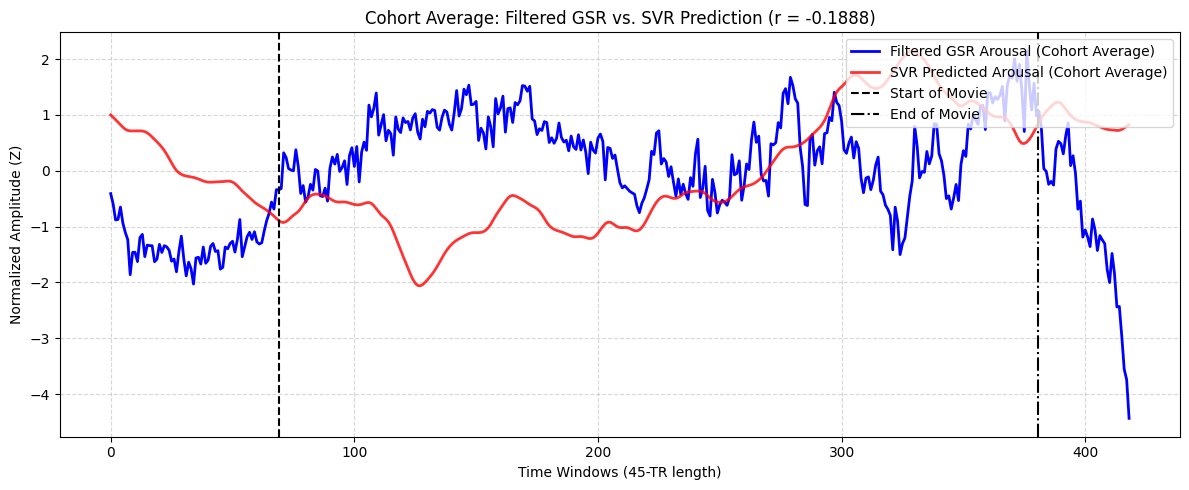

In [20]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# --- High-Pass Filter Function ---
def remove_tonic_drift(data, fs, cutoff=0.01):
    """Removes slow tonic baseline drift to isolate phasic arousal spikes."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(1, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

# 1. Setup and Load Predictions
base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis'
pred_path = os.path.join(base_dir, r'01_Aim_1_fMRI_to_ARS\05_extracted_features\Predicted_Arousal_Chatter.npy')
physio_dir = os.path.join(base_dir, r'data\output_sorted_by_movie\Chatter')

predicted_arousal = np.load(pred_path)
tsv_files = sorted(glob.glob(os.path.join(physio_dir, "*_task-Chatter_physio.tsv")))

# Constants
movie_duration_sec = 405.0
tr_duration = 1.3
total_scan_trs = 464
total_scan_sec = total_scan_trs * tr_duration
window_size = 45
n_windows = 419 

processed_gsr_windows = []

print("--- Rapidly Rebuilding Filtered GSR Arrays ---")
for idx, file_path in enumerate(tsv_files):
    df = pd.read_csv(file_path, sep='\t')
    
    # Locate GSR and Trigger columns
    gsr_col = next((col for col in df.columns if any(t in col.lower() for t in ['gsr', 'eda', 'skinconductance'])), df.columns[1] if len(df.columns) > 1 else df.columns[0])
    trigger_col = next((col for col in df.columns if (0 in df[col].values) and (5 in df[col].values)), None)
            
    raw_gsr = df[gsr_col].values
    
    # Trigger Alignment & Filtering
    if trigger_col is not None:
        triggers = df[trigger_col].values
        start_indices = np.where((triggers[:-1] == 0) & (triggers[1:] >= 5))[0]
        end_indices = np.where((triggers[:-1] >= 5) & (triggers[1:] == 0))[0]
        
        if len(start_indices) > 0 and len(end_indices) > 0:
            movie_start_idx = start_indices[0] + 1
            valid_ends = end_indices[end_indices > movie_start_idx]
            movie_end_idx = valid_ends[0] if len(valid_ends) > 0 else len(raw_gsr)
            
            movie_samples = movie_end_idx - movie_start_idx
            fs = movie_samples / movie_duration_sec
            
            scan_start_idx = int(movie_start_idx - (90.0 * fs))
            scan_end_idx = int(scan_start_idx + (total_scan_sec * fs))
            
            pad_front = np.full(abs(scan_start_idx), raw_gsr[0]) if scan_start_idx < 0 else np.array([])
            pad_back = np.full(scan_end_idx - len(raw_gsr), raw_gsr[-1]) if scan_end_idx > len(raw_gsr) else np.array([])
            
            safe_start = max(0, scan_start_idx)
            safe_end = min(len(raw_gsr), scan_end_idx)
            aligned_gsr_raw = raw_gsr[safe_start:safe_end]
            aligned_gsr_raw = np.concatenate([pad_front, aligned_gsr_raw, pad_back])
            
            # --- APPLY HIGH-PASS FILTER HERE ---
            aligned_gsr_raw = remove_tonic_drift(aligned_gsr_raw, fs)
        else:
            aligned_gsr_raw = raw_gsr 
    else:
        aligned_gsr_raw = raw_gsr 
        
    # Interpolate and Window
    original_time = np.linspace(0, total_scan_sec, len(aligned_gsr_raw))
    target_time = np.linspace(0, total_scan_sec, total_scan_trs)
    interpolator = interp1d(original_time, aligned_gsr_raw, kind='linear')
    tr_gsr = interpolator(target_time)
        
    windowed_gsr = np.zeros(n_windows)
    for i in range(n_windows):
        windowed_gsr[i] = np.mean(tr_gsr[i : i + window_size])
        
    processed_gsr_windows.append(windowed_gsr)

processed_gsr_windows = np.array(processed_gsr_windows)

# 2. Calculate the Cohort Averages
print("--- Computing Cohort Correlation ---")
mean_gsr = np.mean(processed_gsr_windows, axis=0)
mean_pred = np.mean(predicted_arousal, axis=0)

# Normalize
norm_mean_gsr = (mean_gsr - np.mean(mean_gsr)) / (np.std(mean_gsr) + 1e-8)
norm_mean_pred = (mean_pred - np.mean(mean_pred)) / (np.std(mean_pred) + 1e-8)

# Correlate
r_group_gsr, p_group_gsr = pearsonr(norm_mean_gsr, norm_mean_pred)

print(f"Group Average Pearson r: {r_group_gsr:.4f}")
print(f"P-value: {p_group_gsr:.4e}")

# 3. Plot the Filtered Cohort Average
plt.figure(figsize=(12, 5))
plt.plot(norm_mean_gsr, label='Filtered GSR Arousal (Cohort Average)', color='blue', linewidth=2)
plt.plot(norm_mean_pred, label='SVR Predicted Arousal (Cohort Average)', color='red', linewidth=2, alpha=0.8)

start_tr = 90 / tr_duration
end_tr = (90 + movie_duration_sec) / tr_duration
plt.axvline(x=start_tr, color='black', linestyle='--', label='Start of Movie')
plt.axvline(x=end_tr, color='black', linestyle='-.', label='End of Movie')

plt.title(f'Cohort Average: Filtered GSR vs. SVR Prediction (r = {r_group_gsr:.4f})')
plt.xlabel('Time Windows (45-TR length)')
plt.ylabel('Normalized Amplitude (Z)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Applying Band-Pass Filter & Rebuilding Timeline ---
--- Computing Cohort Correlation ---
Group Average Pearson r: -0.0937
P-value: 5.5401e-02


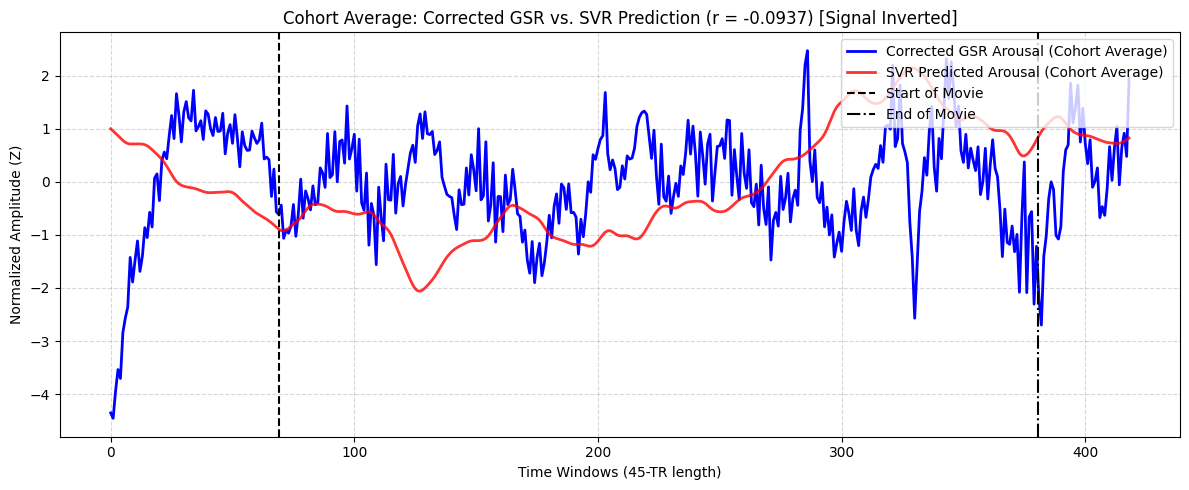

In [21]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# --- 1. Band-Pass Filter Function ---
def apply_bandpass(data, fs, lowcut=0.01, highcut=0.5):
    """Applies a 2nd-order Butterworth band-pass filter to remove both drift and high-frequency noise."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Safety check to ensure high frequency doesn't exceed Nyquist limit
    high = min(high, 0.99)
    b, a = butter(2, [low, high], btype='band', analog=False)
    return filtfilt(b, a, data)

# 2. Setup and Load Predictions
base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis'
pred_path = os.path.join(base_dir, r'01_Aim_1_fMRI_to_ARS\05_extracted_features\Predicted_Arousal_Chatter.npy')
physio_dir = os.path.join(base_dir, r'data\output_sorted_by_movie\Chatter')

predicted_arousal = np.load(pred_path)
tsv_files = sorted(glob.glob(os.path.join(physio_dir, "*_task-Chatter_physio.tsv")))

# Constants & Corrective Toggles
INVERT_SIGNAL = True # Set to True to flip the Resistance vs. Conductance inversion
movie_duration_sec = 405.0
tr_duration = 1.3
total_scan_trs = 464
total_scan_sec = total_scan_trs * tr_duration
window_size = 45
n_windows = 419 

processed_gsr_windows = []

print("--- Applying Band-Pass Filter & Rebuilding Timeline ---")

for idx, file_path in enumerate(tsv_files):
    df = pd.read_csv(file_path, sep='\t')
    
    gsr_col = next((col for col in df.columns if any(t in col.lower() for t in ['gsr', 'eda', 'skinconductance'])), df.columns[1] if len(df.columns) > 1 else df.columns[0])
    trigger_col = next((col for col in df.columns if (0 in df[col].values) and (5 in df[col].values)), None)
            
    raw_gsr = df[gsr_col].values
    
    if trigger_col is not None:
        triggers = df[trigger_col].values
        start_indices = np.where((triggers[:-1] == 0) & (triggers[1:] >= 5))[0]
        end_indices = np.where((triggers[:-1] >= 5) & (triggers[1:] == 0))[0]
        
        if len(start_indices) > 0 and len(end_indices) > 0:
            movie_start_idx = start_indices[0] + 1
            valid_ends = end_indices[end_indices > movie_start_idx]
            movie_end_idx = valid_ends[0] if len(valid_ends) > 0 else len(raw_gsr)
            
            movie_samples = movie_end_idx - movie_start_idx
            fs = movie_samples / movie_duration_sec
            
            # --- CORRECTION 1: FILTER FIRST (Across the entire raw recording) ---
            # Filtering before slicing prevents the massive edge drop-off artifact
            filtered_raw_gsr = apply_bandpass(raw_gsr, fs)
            
            # --- CORRECTION 2: INVERT SIGNAL ---
            if INVERT_SIGNAL:
                filtered_raw_gsr = filtered_raw_gsr * -1
            
            # --- CORRECTION 3: SLICE AND PAD SAFELY ---
            scan_start_idx = int(movie_start_idx - (90.0 * fs))
            scan_end_idx = int(scan_start_idx + (total_scan_sec * fs))
            
            pad_front = np.full(abs(scan_start_idx), filtered_raw_gsr[0]) if scan_start_idx < 0 else np.array([])
            pad_back = np.full(scan_end_idx - len(filtered_raw_gsr), filtered_raw_gsr[-1]) if scan_end_idx > len(filtered_raw_gsr) else np.array([])
            
            safe_start = max(0, scan_start_idx)
            safe_end = min(len(filtered_raw_gsr), scan_end_idx)
            aligned_gsr_raw = filtered_raw_gsr[safe_start:safe_end]
            aligned_gsr_raw = np.concatenate([pad_front, aligned_gsr_raw, pad_back])
            
        else:
            aligned_gsr_raw = raw_gsr 
    else:
        aligned_gsr_raw = raw_gsr 
        
    # Interpolate and Window
    original_time = np.linspace(0, total_scan_sec, len(aligned_gsr_raw))
    target_time = np.linspace(0, total_scan_sec, total_scan_trs)
    
    # Fill_value extrapolate ensures edge safety during TR mapping
    interpolator = interp1d(original_time, aligned_gsr_raw, kind='linear', fill_value="extrapolate")
    tr_gsr = interpolator(target_time)
        
    windowed_gsr = np.zeros(n_windows)
    for i in range(n_windows):
        windowed_gsr[i] = np.mean(tr_gsr[i : i + window_size])
        
    processed_gsr_windows.append(windowed_gsr)

processed_gsr_windows = np.array(processed_gsr_windows)

# 3. Calculate the Cohort Averages
print("--- Computing Cohort Correlation ---")
mean_gsr = np.mean(processed_gsr_windows, axis=0)
mean_pred = np.mean(predicted_arousal, axis=0)

# Normalize
norm_mean_gsr = (mean_gsr - np.mean(mean_gsr)) / (np.std(mean_gsr) + 1e-8)
norm_mean_pred = (mean_pred - np.mean(mean_pred)) / (np.std(mean_pred) + 1e-8)

# Correlate
r_group_gsr, p_group_gsr = pearsonr(norm_mean_gsr, norm_mean_pred)

print(f"Group Average Pearson r: {r_group_gsr:.4f}")
print(f"P-value: {p_group_gsr:.4e}")

# 4. Plot the Corrected Cohort Average
plt.figure(figsize=(12, 5))
plt.plot(norm_mean_gsr, label='Corrected GSR Arousal (Cohort Average)', color='blue', linewidth=2)
plt.plot(norm_mean_pred, label='SVR Predicted Arousal (Cohort Average)', color='red', linewidth=2, alpha=0.8)

start_tr = 90 / tr_duration
end_tr = (90 + movie_duration_sec) / tr_duration
plt.axvline(x=start_tr, color='black', linestyle='--', label='Start of Movie')
plt.axvline(x=end_tr, color='black', linestyle='-.', label='End of Movie')

title_str = f'Cohort Average: Corrected GSR vs. SVR Prediction (r = {r_group_gsr:.4f})'
if INVERT_SIGNAL:
    title_str += " [Signal Inverted]"

plt.title(title_str)
plt.xlabel('Time Windows (45-TR length)')
plt.ylabel('Normalized Amplitude (Z)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()